# NN‑kNN: Regression Sample Notebook

This notebook demonstrates how to use **NN‑kNN** for a regression task.
It trains on a synthetic dataset and evaluates with RMSE and an observed vs. predicted plot.

**Prereqs:** `nnknn_model.py` should be in the same folder as this notebook.

In [1]:
import sys
print(sys.executable)


c:\venvs\nnknn311\Scripts\python.exe


In [2]:
import os, sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from datasets.reg_data import Reg_data, standardize_tensor

# Detect Colab
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # Assumes drive is already mounted in a previous cell
    PROJECT_ROOT = Path("/content/drive/MyDrive/NN-kNN")
    DATA_ROOT    = Path("/content/datasets")
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running on Colab.")
else:
    PROJECT_ROOT = Path(os.getcwd())          # notebook's current folder as project root
    DATA_ROOT    = PROJECT_ROOT / "datasets"
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running locally.")

# Make project importable and set CWD to project root for consistent relative paths
# Add PROJECT_ROOT to sys.path *before* importing from within the project
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)


from model.nnknn_model import NN_KNN_Model, train_model, default_args, GlocalFeatureWeight
from model.mlkr import run_mlkr_sklearn
# from datasets.reg_data import Reg_data, standardize_tensor

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT     =", DATA_ROOT)
print("CHECKPOINTS  =", CHECKPOINTS)

# Optional: pick device
try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
except Exception as e:
    print("Torch not available (only matters if you need it):", e)

Running locally.
PROJECT_ROOT = g:\My Drive\NN-kNN
DATA_ROOT     = g:\My Drive\NN-kNN\datasets
CHECKPOINTS  = g:\My Drive\NN-kNN\checkpoints
Using device: cuda


# Data Sets

## Basic Setup

In [3]:
import os, random
import numpy as np
import torch

def seed_everything(seed: int = 42, deterministic: bool = True):
    # --- Python / OS ---
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)

    # --- NumPy ---
    np.random.seed(seed)

    # --- PyTorch (CPU + GPU) ---
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        # cuDNN settings (conv nets, etc.)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # For Ampere+ GPUs: make matmul deterministic-ish
        # (needed for some ops; safe to set)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

        # Enforce deterministic algorithms (will throw if something is nondeterministic)
        torch.use_deterministic_algorithms(True)

        # Optional: avoid TF32 differences across runs (can change numerics slightly)
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

seed_everything(42, deterministic=True)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

regime_weights = False

def plot_y_distribution(y, bin_width=0.1, title="y distribution", show_kde=False):
    """
    Plot a histogram of y with fixed bin width (default 0.1).

    Args:
        y: list | np.ndarray | pd.Series | torch.Tensor
        bin_width: float, width of each bin
        title: str
        show_kde: bool, overlay a simple kernel density (optional)
    """
    # to numpy
    try:
        import torch
        if isinstance(y, torch.Tensor):
            y = y.detach().cpu().numpy()
    except Exception:
        pass
    y = np.asarray(y, dtype=float).ravel()
    y = y[~np.isnan(y)]

    # bins
    y_min, y_max = np.min(y), np.max(y)
    # include the rightmost edge
    bins = np.arange(np.floor(y_min/bin_width)*bin_width,
                     np.ceil(y_max/bin_width)*bin_width + bin_width,
                     bin_width)

    # plot
    plt.figure(figsize=(7,4.5))
    counts, edges, _ = plt.hist(y, bins=bins, edgecolor='black', alpha=0.8)
    plt.xlabel("y")
    plt.ylabel("count")
    plt.title(f"{title} (bin={bin_width})")

    # optional KDE (very light, no seaborn)
    if show_kde:
        from scipy.stats import gaussian_kde
        xs = np.linspace(edges[0], edges[-1], 512)
        kde = gaussian_kde(y, bw_method='scott')
        # scale KDE to histogram counts
        plt.plot(xs, kde(xs) * len(y) * bin_width, linewidth=2)

    plt.tight_layout()
    plt.show()
    return counts, edges

## Generate a synthetic regression dataset
Two variants are shown below. Uncomment the one you prefer:
- Linear with noise
- Nonlinear (sine) with noise

### Linear Regression

In [5]:
# --- Choose one synthetic dataset ---

N = 3000 # N = 3000
D = 5
torch.manual_seed(42)

# Linear with noise (default)
X = torch.randn(N, D)
true_w = torch.tensor([2.5, -1.7, 0.0, 0.9, 3.2]).view(-1, 1)
rand_scale = 1.0 #1.0 # 0.5
y = X @ true_w + rand_scale*torch.randn(N, 1)  # shape [N,1]

# # Nonlinear (sine) with noise — comment out the linear block above and use this instead
# N = 3000
# X = torch.linspace(-3.0, 3.0, N).unsqueeze(1)
# y = torch.sin(2 * X) + 0.2*torch.randn_like(X)

print(X.shape, y.shape)
#a tensor for the true feature weights


torch.Size([3000, 5]) torch.Size([3000, 1])


In [6]:
# Use absolute value (or squared) as similarity weights
true_feature_weights = true_w.squeeze().abs()  # shape [D]
# Optionally normalize to sum to 1, so comparable for different artificially generated datasets
true_feature_weights = true_feature_weights / true_feature_weights.sum()

print("True feature weights for similarity:", true_feature_weights)

True feature weights for similarity: tensor([0.3012, 0.2048, 0.0000, 0.1084, 0.3855])


### Mixture of two linear models

In [5]:
import torch

#important flag
regime_weights = True

# --- Config ---
torch.manual_seed(42)
N = 3000         # total samples
D = 4            # number of features
noise_scale = 0.0

# --- Define two different weight vectors (two regimes) ---
# Regime 1: depends on features 0,1,2
w1 = torch.tensor([2.5, -1.5,  0.0, 0.0]).view(D, 1)

# Regime 2: depends on features 3,4,5
w2 = torch.tensor([0.0, 0.0,  -2.0, 1.5 ]).view(D, 1)

# (Optional) store normalized "true feature weights" per regime for later comparison
w1_abs = w1.squeeze().abs()
w2_abs = w2.squeeze().abs()
true_feature_weights_regime1 = w1_abs / w1_abs.sum()
true_feature_weights_regime2 = w2_abs / w2_abs.sum()

true_feature_weights_glocal = torch.stack(
    [true_feature_weights_regime1, true_feature_weights_regime2], dim=0
)  # shape [2, D]
print("True glocal feature weights (regime 1, regime 2):")
print(true_feature_weights_glocal)

# --- Generate X ---
X = torch.randn(N, D)  # standard normal features

# --- Assign each sample to a regime (50/50) ---
regime_labels = torch.zeros(N, dtype=torch.long)
regime_labels[: N // 2] = 0  # first half: regime 1
regime_labels[N // 2 :] = 1  # second half: regime 2

# Randomly permute so they are mixed
perm = torch.randperm(N)
regime_labels = regime_labels[perm]
X = X[perm]

# --- Generate y based on the assigned regime ---
y = torch.zeros(N, 1)

# Regime 1 samples
idx1 = (regime_labels == 0)
X1 = X[idx1]
y[idx1] = X1 @ w1 + noise_scale * torch.randn(X1.size(0), 1)

# Regime 2 samples
idx2 = (regime_labels == 1)
X2 = X[idx2]
y[idx2] = X2 @ w2 + noise_scale * torch.randn(X2.size(0), 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Regime 1 samples:", idx1.sum().item(), "Regime 2 samples:", idx2.sum().item())


True glocal feature weights (regime 1, regime 2):
tensor([[0.6250, 0.3750, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.5714, 0.4286]])
X shape: torch.Size([3000, 4])
y shape: torch.Size([3000, 1])
Regime 1 samples: 1500 Regime 2 samples: 1500


### Redundant Features

x0 is with s1, and x1, x2, are working equally strongly on s2. s1 and s2 are equally strong signal. In my experiment, I will also modify a little the workflow. Stage 1: I will first set both w0 w1 to be 0. Stage 2.1: Then w1 to unfreeze,. Stage 2.2: Then manually set w1 and retrain. Stage 3: from stage 2.2, Then w0 to unfreeze; from stage 2.2, then manually w0 and retrain.

Goal:

Two independent latent signals,
𝑠
1
s
1
	​

 and
𝑠
2
s
2
	​

, equally strong in
𝑦
y.

x0: good sensor for
𝑠
1
s
1
	​

.

x1, x2: equally strong sensors for
𝑠
2
s
2
	​

.

x3, x4: noise.

So both “axes” (s1 and s2) are equally important for prediction, but which sensors you emphasize is an explanation choice.

In [5]:
N = 1500
D = 5
torch.manual_seed(42)

# Latent signals
s1 = torch.randn(N, 1)  # first underlying factor
s2 = torch.randn(N, 1)  # second underlying factor

# Sensors:
# x0: good sensor for s1
# x1, x2: equally good sensors for s2
x0 = s1 + 0.05 * torch.randn(N, 1)        # feature 0: s1 + small noise
x1 = s2 + 0.05 * torch.randn(N, 1)        # feature 1: s2 + small noise
x2 = s2 + 0.05 * torch.randn(N, 1)        # feature 2: s2 + small noise (redundant with x1)
# x3 = torch.randn(N, 1)                    # feature 3: pure noise

X = torch.cat([x0, x1, x2], dim=1)   # [N, 4]

# Target: s1 and s2 equally strong in y
rand_scale = 0.1
y = 1.0 * s1 + 1.0 * s2 + rand_scale * torch.randn(N, 1)

print(X.shape, y.shape)

# "Expert" feature weights:
# we eventually want the model to treat x0 as the main s1 sensor,
# and x1/x2 as main s2 sensors, e.g., symmetric on s2.
true_w = torch.tensor([2.0, 1.0, 1.0]).view(-1, 1)

true_feature_weights = true_w.squeeze().abs()
true_feature_weights = true_feature_weights / true_feature_weights.sum()
print("True feature weights for similarity:", true_feature_weights)


torch.Size([1500, 3]) torch.Size([1500, 1])
True feature weights for similarity: tensor([0.5000, 0.2500, 0.2500])


## Split Data

In [6]:
# Simple manual split (80/20)
n_train = int(0.8 * X.size(0))
indices = torch.randperm(X.size(0))
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train, y_train = X[train_idx], y[train_idx].squeeze(1)  # y shape [N]
X_val,   y_val   = X[val_idx],   y[val_idx].squeeze(1)

if regime_weights:
    regime_labels_train = regime_labels[train_idx]
    regime_labels_val = regime_labels[val_idx]

print('Train:', X_train.shape, y_train.shape, '| Val:', X_val.shape, y_val.shape)

Train: torch.Size([1200, 3]) torch.Size([1200]) | Val: torch.Size([300, 3]) torch.Size([300])


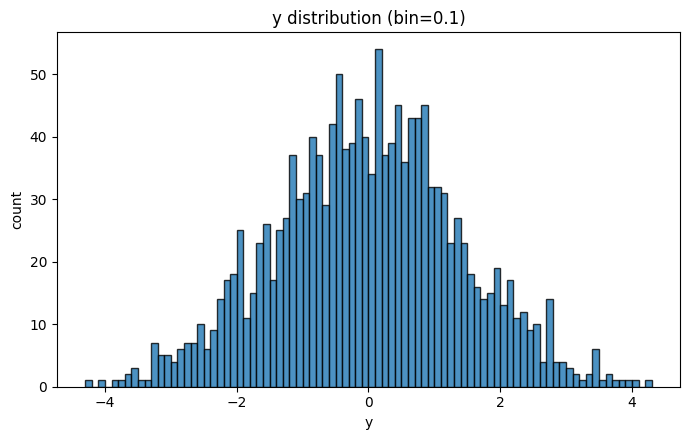

In [7]:
# Example:
counts, edges = plot_y_distribution(y, bin_width=0.1)


In [8]:
y.std()

tensor(1.4040)

## Various Reg Data


In [5]:
# dataset_name = 'yacht'
# dataset_name = 'califonia_housing'  
# dataset_name = 'body_fat'
# dataset_name = 'student_performance'
# dataset_name = 'airfoil'
dataset_name = 'car'
# dataset_name = 'psych_depression_physical_symptons_reg'

Xs, ys = Reg_data(dataset_name)   # Xs, ys are already standardized

print(Xs.shape, ys.shape)
print("y mean:", ys.mean().item(), "y std:", ys.std().item())
print("Raw y min/max:", ys.min().item(), ys.max().item())

torch.Size([6629, 7]) torch.Size([6629, 1])
y mean: 44037.4921875 y std: 59798.80859375
Raw y min/max: 2000.0 548800.0


In [6]:
# for dataset "psych_depression_physical_symptons"
columns = ['1. Most of the time I have difficulty concentrating on simple tasks', "2. I don't feel like doing my daily duties", '3. My friends or family have told me that I look different', '4. When I think about the future it is difficult for me to imagine it clearly', '5. People around me often ask me how I feel', '6. I consider that my life is full of good things', '7. My hobbies are still important to me', "8. I'm still as punctual as I have always been", '9. If I had the chance, I would spend all day in my bed', '10. I have found that I can spend a lot of time scrolling the screen \nof my cell phone without searching or stopping at anything in particular', '11. When someone asks me something, I have noticed that I take longer than normal to\nrespond', '12. I have noticed my body shaken without any cause', '13. I felt more encouraged to do my daily activities before', "14. Sometimes I wake up sad and I can't explain why", '15. In recent months I usually reproach myself for things from the past', '16. I think my thoughts are strange or different from before', '17. I feel guilty about the decisions that I have made', "18. I don't feel as comfortable with my body as I did before", "19. I don't feel successful compared to others", '20. It is difficult for me to make decisions even if they are simple', "21. I'm capable of achieving what I propose to myself", '22. It is not difficult for me to understand something the first time', '23. I have thought more than before about what my death would be like', '24. Being dead seems to be a solution to some problems', '25. I would rather stay home than go out with my friends', '26. I like to attend family gatherings', '27. I feel excited when thinking about my life project', '28. The decisions I have made so far have been the right ones', '29. I am able to carry out my activities as I have always been', '30. I like to be in touch with my friends and family through social media', '31. It is easy for me to choose a photograph of myself to show it on social media', '32. I am proud of what I have achieved so far', '33. I have trouble remembering things easily', '34. In recent months I have had discussions with my schoolmates or colleagues', '35. I constantly imagine that something will go wrong at my work or at school', '36. I am afraid of being worng when doing my homework', "37. I'm not too worried about what might happen in a few weeks", "38. Lately it's hard for me to calm down", '39. Everything will be alright', '40. I can easily blank my mind', '41. I am bothered by insignificant things that were not important before', '42. I find it uncomfortable to be in a crowded place', '43. Sometimes i feel trapped', '44. I am easily frightened by unexpected noises', '45. I have difficulties to do one task at a time', '46. I have the feeling that I am forgetting to do something', '47. I can clearly express to others how I feel', '48. I can sleep easily', '49. I enjoy every moment of the day', '50. I imagine that at any moment a disaster of the\nnature may occur', '51. Sometimes I feel like I get tired easily', '52. Being locked in an elevator would be the worst thing that could happen to me', "53. I'm bothered by people walking slowly in front of me ", "54. I don't usually get upset if something doesn't go as expected", '55. Sometimes it is as if some conversations with friends or family become\ninterrogations', '56. I manage my schedule as I always have', '57. It bothers me to feel that people on the street approach me', '58. I have no difficulty understanding what people explain to me', '59. I consider that I am good at controlling my emotions', '60. In new situations I feel calm and encouraged', '61. Sometimes I forget what I wanted to say because I have several thoughts at the same time', '62. I would like to know what will happen in the future', '63. When I get angry I can easily explode', '64. I can put down my cell phone and dedicate myself to reading without distractions', '65. I worry that people will not understand what I mean.', '66. Sometimes I do not listen to what people say to me because I am thinking about other things', '67. I get angry easily', "68. I'm afraid that something bad could happen to me", '69. It is not important for me to meet set dates', '70. I like to think clearly before giving my opinion', '71. I use lies just to get out of certain problems', '72. If I have the opportunity to get in line to avoid wasting time, I do it', '73. I have difficulty making elaborate plans', '74. People have problems because of themselves', '75. No me parece importante lo que los otros piensen sobre mí', '76. Laws are not as important as others think', '77. I would regret betraying a friend', '78. I prefer that a negotiation supports the largest possible number of people involved', '79. It is easy for me to work in a team', '80. It is important to help people when they need it', '81. I have punched someone or thought of doing it', '82. If it was necessary I would pretend to be someone else to get something', '83. I consider it important to ensure my physical safety and that of those around me', '84. After an argument I usually go over what happened in my head', '85. I have a hard time controlling myself when I get angry', '86. Loyalty is important', "87. If I can help a person I will stop what I'm doing to help him", '88', '89. It makes me laugh when my superiors at school or at work demand something', '90. Deceiving people is not wrong if it is to achieve something important', '91. I like to greet my neighbors', '92. It does not seem serious to me to have some debts', '93. People steal because they have needs', '94. I lose control easily', "95. Neighbors must put up with each other's noises without complaining", '96. Littering on public roads is wrong', '97. People who commit crimes have their reasons for doing it', '98. It is normal to change jobs several times a year', '99. It is important to respect turns', '100. I could pretend to be someone else to achieve what I want', '101. I consider it important that all people have the same rights', '102. I have a hard time taking  "no" for an answer']

KeyboardInterrupt: 

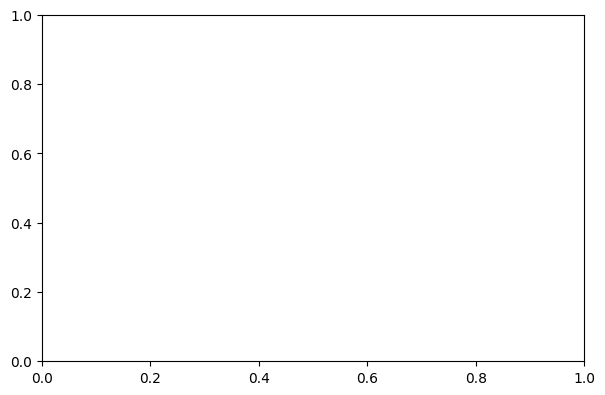

In [7]:
counts, edges = plot_y_distribution(ys, bin_width=0.1)


In [8]:
X = Xs
y = ys
# Simple manual split (80/20)
n_train = int(0.8 * X.size(0))
indices = torch.randperm(X.size(0))
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train, y_train = X[train_idx], y[train_idx]  # y shape [N]
X_val,   y_val   = X[val_idx],   y[val_idx]

print('Train:', X_train.shape, y_train.shape, '| Val:', X_val.shape, y_val.shape)

Train: torch.Size([5303, 7]) torch.Size([5303, 1]) | Val: torch.Size([1326, 7]) torch.Size([1326, 1])


## Standardize Data

In [9]:
X_train_raw, X_val_raw = X_train.clone(), X_val.clone()
y_train_raw, y_val_raw = y_train.clone(), y_val.clone()
y_mean_raw = y_train_raw.mean().item()
y_std_raw  = y_train_raw.std().item()

# X: per-feature z-score using TRAIN stats only (overwrite)
X_train, X_mean, X_std = standardize_tensor(X_train, dim=0, return_stats=True)
X_val = standardize_tensor(X_val, dim=0, mean=X_mean, std=X_std)

# y: scalar z-score using TRAIN stats only (overwrite)
y_train, y_mean, y_std = standardize_tensor(y_train.view(-1, 1), dim=0, return_stats=True)
y_train = y_train.view(-1)
y_val = standardize_tensor(y_val.view(-1, 1), dim=0, mean=y_mean, std=y_std).view(-1)

# --- Aliases to keep older cells working ---
X_train_z, X_val_z = X_train, X_val
y_train_z, y_val_z = y_train, y_val
y_train_norm, y_val_norm = y_train, y_val

# --- Sanity checks (should be ~0 mean, ~1 std) ---
print("X_train mean abs (avg):", X_train.mean(0).abs().mean().item())
print("X_train std  (min/mean/max):",
      X_train.std(0).min().item(), X_train.std(0).mean().item(), X_train.std(0).max().item())
print("y_train mean/std:", y_train.mean().item(), y_train.std().item())



X_train mean abs (avg): 1.3775295570894741e-08
X_train std  (min/mean/max): 0.9999999403953552 1.0 1.0
y_train mean/std: -1.5894572324981482e-09 1.0


# Model Code

## Configure NN‑kNN for regression

In [ ]:
cfg = {
    **default_args,
    "task_type": "regression",

    "case_score_mode": "bias_minus_distance",  
    # "hard_knn",      # start here (closest to KNN)
    # other options you can try:
    # "bias_minus_distance"
    # "neg_distance_logw"
    # "sigmoid"                (your old style, if you want it back)
    # "hard_knn"               (uniform KNN weights)

    "softmax_over_cases": True,      # model enforces True in regression; kept explicit for clarity
    "tau": 1.0,                      # attention sharpness over cases, lower -> sharper
    "case_normalizer": "sparsemax",  # 'softmax' | 'sparsemax' | 'entmax15'
    # "case_norm_warmup_epochs": 0,       # 50–200 is a good sweep， 0 if no warm-up
    # "case_norm_warmup_type": "softmax",   # warm-up normalizer
    
    #for locality regularization in regression
    "regression_locality": False,  # Whether to use locality regularization in regression training
    "lambda_base": 1.0,
    # "lambda_kl": 0.0,        # weight for KL(p||w) attention-to-label proximity (regression only)
    "locality_alpha" : 2.0,    # exponent for distance in locality regularization
    "lambda_expdist": 0.1,   #1.0, weight for expected distance loss (regression only)
    # "lambda_balance": 0.0,    # weight for signed-bias regularizer (regression only)
    # "lambda_cover": 0.0,     #0.5, weight for coverage loss (regression
    # "lambda_pair": 0.0,      #0.5, weight for pos>neg pairwise hinge (regression only)
    # "lambda_ent": 0.0,  # 0.0,      #1e-3, tiny entropy penalty (encourages sparse attention tails)
    # "eps_sigma_multiplier": 0.1, #0.2,0.4 multiplier for sigma_y to define "close" and "far" in pairwise loss
    # "pairwise_margin": 0.05, # required gap: w_pos - w_neg >= margin

    # "locality_warmup_epochs": 0,   # epochs with locality off
    # "locality_ramp_epochs": 0,   # linearly ramp to full strength
    # "locality_schedule": "linear",  # (only linear implemented below)

    # "pre_topk_mask": False,   # enable the pre-normalization K-sparsification, if turned on, this influences nn-cdh to only adapt to top_k neighbors
    # "top_k": 40,         # K for Neighbor Agreement / nDCG in validation and also for explanation mode

    ## NEW
    # "bias_manual_set": True,
    # "bias_manual_value": 0.0,
    # #loss in the main training loop
    # "lambda_case_bias": 1e-3, #1e-3,    # weight for L2 regularization on case bias terms

    # "glocal_fw_set_num": 1, #1
    # "neg_weight_flag": False,        # regression should NOT use negative class weights
    # "sampling_cases_flag": False,    # use all cases for stable regression
    # "case_activation_by_top_k_average": True,  # use percentile-based bias finder
    # "top_k_for_default_case_activation": 20, #mark.
    # "case_activation_default_percentage": 0.1,
    "training_epochs": 7000,
    "batch_size": 64,
    "feature_extractor_lr": 1e-3, #1e-3,1e-4,1e-3,
    "glocal_weightor_lr": 1e-3, #1e-3,5e-4, 1e-3, influence feature weights and glocal weights
    "case_net_lr": 3e-4, #3e-4,1e-4,1e-5,
    "checkpoint_path": "nnknn_regression_best.pth",
    "patience": 80,

    #default feature extractor
    "post_mlp_enabled": False,
    # "post_mlp_dims": (64, 32),
    # "post_mlp_dropout": 0.1,
    # "post_mlp_activation": "relu",

    #Turn them all True or False to turn on/off nn_cdh adaptation
    "nn_cdh_pretrain": False,  # Whether to pretrain nn_cdh adapter
    "use_nn_cdh": False,
    "cdh_aggregate": False,  # "weighted_sum" | "attention"

    "explanation_mode": True
}

# No feature extractor for tabular demo
feature_extractor = None

## Redundant Features: Alternative Train: Feature Injection Experiment

In [ ]:
alternative_training_for_feature_injection_exp = True

In [24]:
# if alternative_training_for_feature_injection_exp:
#     cfg = {
#         **default_args,
#         "task_type": "regression",
#         "softmax_over_cases": True,      # model enforces True in regression; kept explicit for clarity
#         "tau": 1.0,                      # attention sharpness over cases, lower -> sharper
#         "case_normalizer": "sparsemax", #"sparsemax",  # 'softmax' | 'sparsemax' | 'entmax15'

#         ###NEWLY ADDED###!!!!
#         "post_mlp_enabled": False,
#         "post_mlp_dims": (32, 16),
#         "post_mlp_dropout": 0.1,
#         "post_mlp_activation": "relu",

#         #loss in the main training loop
#         "lambda_case_bias": 1e-3,    # weight for L2 regularization on case bias terms

#         #for locality regularization in regression
#         "regression_locality": True,  # Whether to use locality regularization in regression training
#         "lambda_base": 1.0,
#         "lambda_kl": 0.0,        # weight for KL(p||w) attention-to-label proximity (regression only)
#         "locality_alpha" : 2.0,    # exponent for distance in locality regularization
#         "lambda_expdist": 0.3,   #1.0, weight for expected distance loss (regression only)
#         "lambda_balance": 0.3,    # weight for signed-bias regularizer (regression only)
#         "lambda_cover": 0.0,     #0.5, weight for coverage loss (regression
#         "lambda_pair": 0.0,      #0.5, weight for pos>neg pairwise hinge (regression only)
#         "lambda_ent": 1e-3,  # 0.0,      #1e-3, tiny entropy penalty (encourages sparse attention tails)
#         "eps_sigma_multiplier": 0.1, #0.2,0.4 multiplier for sigma_y to define "close" and "far" in pairwise loss
#         "pairwise_margin": 0.05, # required gap: w_pos - w_neg >= margin

#         "pre_topk_mask": False,   # enable the pre-normalization K-sparsification, if turned on, this influences nn-cdh to only adapt to top_k neighbors
#         "top_k": 20,         # K for Neighbor Agreement / nDCG in validation and also for explanation mode

#         "glocal_fw_set_num": 1, #1
#         "neg_weight_flag": False,        # regression should NOT use negative class weights
#         "sampling_cases_flag": False,    # use all cases for stable regression

#         "case_activation_by_top_k_average": False,  # use percentile-based bias finder
#         "top_k_for_default_case_activation": 10, #mark.
#         "case_activation_default_percentage": 0.1,
#         "training_epochs": 800,
#         "batch_size": 64,
#         "feature_extractor_lr": 1e-4, #1e-4,1e-3,
#         "glocal_weightor_lr": 5e-4, #1e-3, influence feature weights and glocal weights
#         "case_net_lr": 1e-4, #1e-4,1e-3,
#         "checkpoint_path": "nnknn_regression_best.pth",
#         "patience": 40,

#         "nn_cdh_pretrain": False,  # Whether to pretrain nn_cdh adapter
#         "use_nn_cdh": False,

#         "explanation_mode": True
#     }

#     # No feature extractor for tabular demo
#     feature_extractor = None
#     # y_mean = y_train.mean()
#     # y_std = y_train.std().clamp(min=1e-6)
#     # y_train_norm = (y_train - y_mean) / y_std
#     # y_val_norm   = (y_val   - y_mean) / y_std
#     y_train_norm = y_train
#     y_val_norm   = y_val

In [25]:
if alternative_training_for_feature_injection_exp:
    ## ============================================================
    ## Feature Injection Experiment (A, B.1, B.2, C.1, C.2) with normalized y
    ## ============================================================

    import copy
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader

    # --- Use normalized y, consistent with main training ---
    X_train_dev = X_train.to(device)
    X_val_dev   = X_val.to(device)
    y_train_dev = y_train_norm.to(device)
    y_val_dev   = y_val_norm.to(device)

    D = X_train_dev.shape[1]
    assert true_feature_weights.shape[0] == D, "Dim mismatch between true_feature_weights and X."

    # Make a cfg copy for this experiment; turn off NN-CDH (keep locality as in cfg)
    cfg_inj = {**cfg}
    cfg_inj["use_nn_cdh"] = False  # keep NN-CDH out of this toy experiment
    cfg_inj["regression_locality"] = False  #ablation, model is easier to learn

    batch_size = cfg_inj.get("batch_size", 256)
    criterion  = nn.MSELoss()

    train_loader = DataLoader(
        TensorDataset(X_train_dev, y_train_dev),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val_dev, y_val_dev),
        batch_size=batch_size,
        shuffle=False
    )

    def make_model_with_glocal(glocal_weightor, cfg_local):
        """
        Build an NN_KNN_Model for regression with given glocal_weightor.
        Uses normalized y, no NN-CDH (adapter=None).
        """
        ys = y_train_dev.float().unsqueeze(1)  # [N, 1]
        model = NN_KNN_Model(
            X_train_dev, ys,
            feature_extractor=feature_extractor,
            glocal_weightor=glocal_weightor,
            nn_cdh=None,
            **cfg_local
        ).to(device)
        return model

    def build_optimizer_like_train_model(model, glocal_weightor, feature_extractor, adapter, cfg_local):
        """
        Build an Adam optimizer with the same parameter grouping / LRs
        as in train_model.
        """
        # Separate parameters for different learning rates
        feature_extractor_params = []
        if feature_extractor is not None:
            feature_extractor_params = list(feature_extractor.parameters())

        glocal_weightor_params = []
        if glocal_weightor is not None:
            glocal_weightor_params = list(glocal_weightor.parameters())

        adapter_params = []
        if adapter is not None:
            adapter_params = list(adapter.parameters())

        shared_ids = {id(p) for p in (feature_extractor_params + glocal_weightor_params + adapter_params)}
        case_net_params = [p for p in model.parameters() if id(p) not in shared_ids]

        fe_lr       = cfg_local.get("feature_extractor_lr", default_args["feature_extractor_lr"])
        glocal_lr   = cfg_local.get("glocal_weightor_lr",  default_args["glocal_weightor_lr"])
        adapter_lr  = cfg_local.get("adapter_lr",          default_args["adapter_lr"])
        case_net_lr = cfg_local.get("case_net_lr",         default_args["case_net_lr"])

        optimizer = torch.optim.Adam([
            {'params': feature_extractor_params, 'lr': fe_lr},
            {'params': glocal_weightor_params,   'lr': glocal_lr},
            {'params': adapter_params,           'lr': adapter_lr},
            {'params': case_net_params,          'lr': case_net_lr},
        ], weight_decay=1e-5)

        return optimizer

    def train_phase(model, optimizer, num_epochs, frozen_feature_idxs=None):
        """
        Train for num_epochs; optionally freeze a list of feature indices
        in glocal_weightor.feature_weights by zeroing their gradients.
        """
        if frozen_feature_idxs is None:
            frozen_feature_idxs = []
        for epoch in range(num_epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                final_predictions, predicted_solution, pre_adapted_solution, topk_cases, topk_labels, topk_acts = model(xb)
                loss = criterion(final_predictions.squeeze(1), yb.float())
                loss.backward()
                if frozen_feature_idxs:
                    with torch.no_grad():
                        if model.glocal_weightor.feature_weights.grad is not None:
                            for j in frozen_feature_idxs:
                                model.glocal_weightor.feature_weights.grad[:, j] = 0.0
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                optimizer.step()

    def eval_model(model):
        model.eval()
        preds = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                final_predictions, predicted_solution, pre_adapted_solution, topk_cases, topk_labels, topk_acts = model(xb)
                preds.append(final_predictions.detach().cpu().view(-1))
        preds = torch.cat(preds, dim=0)
        y = y_val_dev.cpu().view(-1)
        mse = F.mse_loss(preds, y).item()
        ss_res = torch.sum((y - preds) ** 2).item()
        ss_tot = torch.sum((y - y.mean()) ** 2).item()
        r2 = 1.0 - ss_res / ss_tot
        return mse, r2

    def print_feature_weights(prefix, model):
        w = model.glocal_weightor.feature_weights.detach().cpu().view(-1)
        print(f"{prefix} glocal feature weights:", w.numpy())

    glocal_fw_set_num = cfg_inj.get("glocal_fw_set_num", 1)

    # =========================================
    # Stage A: mis-specified prior (w0 = w1 = 0), both frozen
    # =========================================
    print("\n=== Feature Injection: Stage A (w0 = w1 = 0, both frozen) ===")

    glocal_A = GlocalFeatureWeight(feature_dim=D, set_num=glocal_fw_set_num).to(device)

    with torch.no_grad():
        # Start from true_feature_weights but set w0 and w1 to 0
        # w_init = true_feature_weights.to(device).clone()
        # w_init[0] = 0.0
        # w_init[1] = 0.0
        glocal_A.feature_weights.data[0][0] = 0.0
        glocal_A.feature_weights.data[0][1] = 0.0

    model_A = make_model_with_glocal(glocal_A, cfg_inj)
    optimizer_A = build_optimizer_like_train_model(
        model=model_A,
        glocal_weightor=glocal_A,
        feature_extractor=feature_extractor,
        adapter=None,
        cfg_local=cfg_inj
    )

    print_feature_weights("Initial (A)", model_A)
    # Freeze both feature 0 and 1
    train_phase(model_A, optimizer_A, num_epochs=80, frozen_feature_idxs=[0, 1])
    print_feature_weights("After training (A)", model_A)
    mse_A, r2_A = eval_model(model_A)
    print(f"Stage A   - Val MSE: {mse_A:.4f} | Val R²: {r2_A:.4f}")

    # Save checkpoint after A so B.1/B.2 start from the same point
    state_A = copy.deepcopy(model_A.state_dict())

    # Post-hoc fine-tuning budget
    E_extra = 20  # adjust as needed (smaller = clearer injection effect)

    # =========================================
    # Stage B.1: from A, unfreeze w1 (w0 still frozen), no manual edit
    # =========================================
    print("\n=== Feature Injection: Stage B.1 (unfreeze w1, w0 frozen, no manual edit) ===")

    # temporary glocal, will be overwritten by state_A
    glocal_B1 = GlocalFeatureWeight(feature_dim=D, set_num=glocal_fw_set_num).to(device)
    model_B1 = make_model_with_glocal(glocal_B1, cfg_inj)
    model_B1.load_state_dict(state_A)

    optimizer_B1 = build_optimizer_like_train_model(
        model=model_B1,
        glocal_weightor=glocal_B1,
        feature_extractor=feature_extractor,
        adapter=None,
        cfg_local=cfg_inj
    )

    print_feature_weights("Start (B.1)", model_B1)
    # Only freeze w0; w1 now learns
    train_phase(model_B1, optimizer_B1, num_epochs=E_extra, frozen_feature_idxs=[0])
    print_feature_weights("After training (B.1)", model_B1)
    mse_B1, r2_B1 = eval_model(model_B1)
    print(f"Stage B.1 - Val MSE: {mse_B1:.4f} | Val R²: {r2_B1:.4f}")

    # =========================================
    # Stage B.2: from A, manual edit w1 toward true weights, then unfreeze w1 (w0 frozen)
    # =========================================
    print("\n=== Feature Injection: Stage B.2 (manual edit w1 toward true weights + retrain, w0 frozen) ===")

    glocal_B2 = GlocalFeatureWeight(feature_dim=D, set_num=glocal_fw_set_num).to(device)
    model_B2 = make_model_with_glocal(glocal_B2, cfg_inj)
    model_B2.load_state_dict(state_A)

    print_feature_weights("Start (B.2, pre-edit)", model_B2)
    with torch.no_grad():
        w     = model_B2.glocal_weightor.feature_weights.data[0]
        w_tgt = true_feature_weights.to(device)

        # How strongly to move toward our desired values
        alpha_up   = 0.7  # for pushing w1 up
        alpha_down = 0.7  # for pushing w2 down

        # 1) Push w1 toward its "expert" value (favor x1 as main s2 sensor)
        w[1] = (1 - alpha_up) * w[1] + alpha_up * w_tgt[1]

        # 2) Push w2 toward a *smaller* value (discourage relying on x2)
        #    e.g., some fraction of its expert weight, or even close to 0
        desired_w2 = 0.3 * w_tgt[2]   # make x2 clearly less important than x1
        w[2] = (1 - alpha_down) * w[2] + alpha_down * desired_w2

        # 3) Ensure w2 is strictly lower than w1 (just in case)
        if w[2] >= w[1]:
            w[2] = 0.5 * w[1]

        model_B2.glocal_weightor.feature_weights.data[0] = w
        print("Manually nudged w1 up and w2 down:", w.cpu().numpy())

    print_feature_weights("After manual edit (B.2)", model_B2)

    optimizer_B2 = build_optimizer_like_train_model(
        model=model_B2,
        glocal_weightor=glocal_B2,
        feature_extractor=feature_extractor,
        adapter=None,
        cfg_local=cfg_inj
    )

    # Freeze w0, let w1 (and others) adapt
    train_phase(model_B2, optimizer_B2, num_epochs=E_extra, frozen_feature_idxs=[0])
    print_feature_weights("After training (B.2)", model_B2)
    mse_B2, r2_B2 = eval_model(model_B2)
    print(f"Stage B.2 - Val MSE: {mse_B2:.4f} | Val R²: {r2_B2:.4f}")

    # Save checkpoint after B.2 to start C.1 / C.2 from the same s2 configuration
    state_B2 = copy.deepcopy(model_B2.state_dict())

    # =========================================
    # Stage C.1: from B.2, unfreeze w0 (no manual edit on w0)
    # =========================================
    print("\n=== Feature Injection: Stage C.1 (from B.2, unfreeze w0, no manual edit) ===")

    glocal_C1 = GlocalFeatureWeight(feature_dim=D, set_num=glocal_fw_set_num).to(device)
    model_C1 = make_model_with_glocal(glocal_C1, cfg_inj)
    model_C1.load_state_dict(state_B2)

    optimizer_C1 = build_optimizer_like_train_model(
        model=model_C1,
        glocal_weightor=glocal_C1,
        feature_extractor=feature_extractor,
        adapter=None,
        cfg_local=cfg_inj
    )

    print_feature_weights("Start (C.1)", model_C1)
    # Now no frozen indices: both w0 and w1 can adapt
    train_phase(model_C1, optimizer_C1, num_epochs=E_extra, frozen_feature_idxs=[])
    print_feature_weights("After training (C.1)", model_C1)
    mse_C1, r2_C1 = eval_model(model_C1)
    print(f"Stage C.1 - Val MSE: {mse_C1:.4f} | Val R²: {r2_C1:.4f}")

    # =========================================
    # Stage C.2: from B.2, manual edit w0 toward true weights, then unfreeze w0
    # =========================================
    print("\n=== Feature Injection: Stage C.2 (from B.2, manual edit w0 toward true weights + retrain) ===")

    glocal_C2 = GlocalFeatureWeight(feature_dim=D, set_num=glocal_fw_set_num).to(device)
    model_C2 = make_model_with_glocal(glocal_C2, cfg_inj)
    model_C2.load_state_dict(state_B2)

    print_feature_weights("Start (C.2, pre-edit)", model_C2)
    with torch.no_grad():
        w       = model_C2.glocal_weightor.feature_weights.data[0]
        w_tgt   = true_feature_weights.to(device)
        alpha   = 0.7
        w[0]    = (1 - alpha) * w[0] + alpha * w_tgt[0]
        model_C2.glocal_weightor.feature_weights.data[0] = w
        print("Manually nudged w0 toward true weight.", w.cpu().numpy())
    print_feature_weights("After manual edit (C.2)", model_C2)

    optimizer_C2 = build_optimizer_like_train_model(
        model=model_C2,
        glocal_weightor=glocal_C2,
        feature_extractor=feature_extractor,
        adapter=None,
        cfg_local=cfg_inj
    )

    train_phase(model_C2, optimizer_C2, num_epochs=E_extra, frozen_feature_idxs=[])
    print_feature_weights("After training (C.2)", model_C2)
    mse_C2, r2_C2 = eval_model(model_C2)
    print(f"Stage C.2 - Val MSE: {mse_C2:.4f} | Val R²: {r2_C2:.4f}")

    print("\n=== Feature Injection Summary (normalized y) ===")
    print("Lower MSE / higher R² is better.")
    print(f"A    : MSE={mse_A:.4f}  | R²={r2_A:.4f}")
    print(f"B.1  : MSE={mse_B1:.4f} | R²={r2_B1:.4f}")
    print(f"B.2  : MSE={mse_B2:.4f} | R²={r2_B2:.4f}")
    print(f"C.1  : MSE={mse_C1:.4f} | R²={r2_C1:.4f}")
    print(f"C.2  : MSE={mse_C2:.4f} | R²={r2_C2:.4f}")


## Train

In [11]:
if regime_weights:
    cfg["glocal_init_from_true"] = False
    cfg["glocal_init_alpha"] = 1.0   # for a stronger nudge; adjust 0–1
    # After you define true_feature_weights_glocal for the two-regime dataset
    cfg["true_feature_weights_glocal"] = true_feature_weights_glocal  # [S_true, D]

    # (Optional) if you also run single-regime experiments in the same notebook:
    # cfg["true_feature_weights"] = true_feature_weights  # [D], if you have it

In [12]:
#already standardized y
# y_mean = y_train.mean()
# y_std = y_train.std().clamp(min=1e-6)
y_train_norm = y_train # (y_train - y_mean) / y_std
y_val_norm   = y_val   # (y_val   - y_mean) / y_std

In [22]:
#train with normalized y
best_acc, glocal_weightor, model = train_model(
    X_train, y_train_norm, X_val, y_val_norm,
    feature_extractor=feature_extractor,
    cfg=cfg
)

print('Best (R^2 proxy in logs).')

NameError: name 'feature_extractor' is not defined

## Evaluate & visualize

Validation RMSE (z): 0.1678
Validation RMSE (raw): 10121.0166


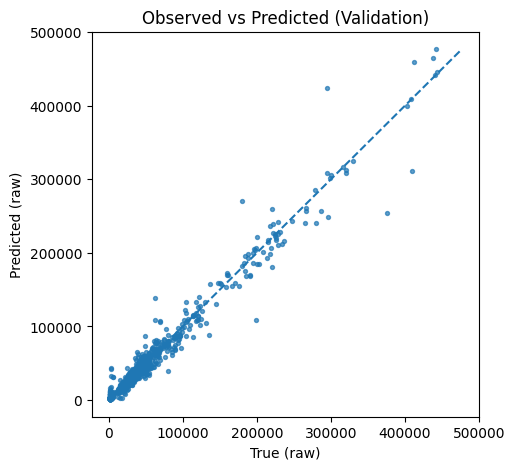

In [14]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

model.eval()
with torch.no_grad():
    preds = []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, *_ = model(X_val[i:i+B].to(device))
        preds.append(yhat.detach().cpu())
    y_pred_z = torch.cat(preds, dim=0).view(-1)
    y_true_z = y_val.view(-1)   # <-- z-space

rmse_z = torch.sqrt(F.mse_loss(y_pred_z, y_true_z)).item()
print(f"Validation RMSE (z): {rmse_z:.4f}")

# Optional: convert to raw units (only if you kept the train-stat scaler)
y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

y_pred_raw = y_pred_z * y_std_t + y_mean_t
y_true_raw = y_true_z * y_std_t + y_mean_t
rmse_raw = torch.sqrt(F.mse_loss(y_pred_raw, y_true_raw)).item()
print(f"Validation RMSE (raw): {rmse_raw:.4f}")

plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation)')
plt.show()


[Z] Pre-adaptation  MSE: 0.027908, RMSE: 0.167057
[Z] Post-adaptation MSE: 0.028148, RMSE: 0.167773
[Z] ΔRMSE (pre - post):  -0.000716
[RAW] Pre-adaptation  RMSE: 10077.812500
[RAW] Post-adaptation RMSE: 10121.016602


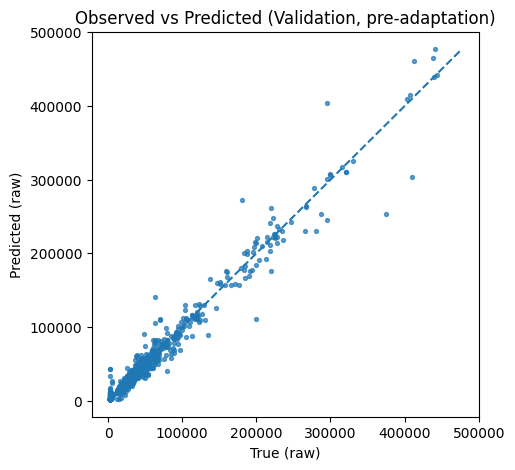

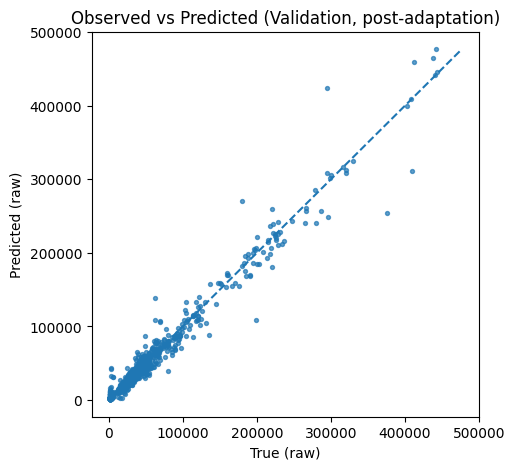

In [15]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    pre_preds, post_preds = [], []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, pre_adapt_yhat, *_ = model(X_val[i:i+B].to(device))

        # pre_adapt_yhat may come in different shapes depending on code path
        if pre_adapt_yhat.dim() == 3:
            pre_yhat = pre_adapt_yhat.sum(dim=1).squeeze(-1)  # [B]
        elif pre_adapt_yhat.dim() == 2:
            pre_yhat = pre_adapt_yhat.squeeze(-1)             # [B]
        else:
            pre_yhat = pre_adapt_yhat                         # [B]

        post_preds.append(yhat.detach().cpu().view(-1))
        pre_preds.append(pre_yhat.detach().cpu().view(-1))

    y_pred_post_z = torch.cat(post_preds, dim=0).to(torch.float32)  # z-space
    y_pred_pre_z  = torch.cat(pre_preds,  dim=0).to(torch.float32)  # z-space
    y_true_z      = y_val.detach().cpu().view(-1).to(torch.float32) # z-space

# --- Metrics in z-space (always correct for training/val consistency) ---
mse_pre_z  = F.mse_loss(y_pred_pre_z,  y_true_z).item()
mse_post_z = F.mse_loss(y_pred_post_z, y_true_z).item()
rmse_pre_z  = mse_pre_z ** 0.5
rmse_post_z = mse_post_z ** 0.5

print(f"[Z] Pre-adaptation  MSE: {mse_pre_z:.6f}, RMSE: {rmse_pre_z:.6f}")
print(f"[Z] Post-adaptation MSE: {mse_post_z:.6f}, RMSE: {rmse_post_z:.6f}")
print(f"[Z] ΔRMSE (pre - post):  {rmse_pre_z - rmse_post_z:.6f}")

# --- Optional: convert to raw units if you saved train-split scaler ---
# (RMSE_raw = RMSE_z * y_std_raw)
y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

y_pred_pre_raw  = y_pred_pre_z  * y_std_t + y_mean_t
y_pred_post_raw = y_pred_post_z * y_std_t + y_mean_t
y_true_raw      = y_true_z      * y_std_t + y_mean_t

rmse_pre_raw  = torch.sqrt(F.mse_loss(y_pred_pre_raw,  y_true_raw)).item()
rmse_post_raw = torch.sqrt(F.mse_loss(y_pred_post_raw, y_true_raw)).item()
print(f"[RAW] Pre-adaptation  RMSE: {rmse_pre_raw:.6f}")
print(f"[RAW] Post-adaptation RMSE: {rmse_post_raw:.6f}")

# Plots in raw units (more interpretable)
plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_pre_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_pre_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_pre_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation, pre-adaptation)')
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_post_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_post_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_post_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation, post-adaptation)')
plt.show()


## (Optional) Explanations — top activated cases

In [61]:
# Enable explanation mode and inspect the top-k contributing cases for a few samples
model.top_k_mode = True
k = model.top_k  # how many top cases to display (see model.top_k_explain default too)

sample_idx = torch.arange(min(5, X_val.size(0)))  # first few
with torch.no_grad():
    final_pred, pred_vals, _, cases, labels, acts = model(X_val[sample_idx].to(device))

final_pred = final_pred * y_std_t + y_mean_t
labels = labels * y_std_t + y_mean_t

print("\n The first few cases and their most activated neighbors: ")
for i in range(len(sample_idx)):
    print(f"\nSample {i} (True: {y_val[sample_idx[i]].item():.4f}, Pred: {final_pred[i].item():.4f}):")
    topk_acts, topk_indices = torch.topk(acts[i], k=k)
    #print the sample itself
    print(f"  Sample features: {X_val[sample_idx[i]].cpu().numpy()}")
    accumulated_label = 0.0
    for rank in range(k):
        case_idx = topk_indices[rank].item()
        case_act = topk_acts[rank].item()
        case_feat = cases[i][rank].cpu().numpy()
        case_label = labels[i][rank].item()
        print(f"  Neighbor {rank+1}: Index {case_idx}, Activation {case_act:.4f}, Label {case_label:.4f}, Features {case_feat}")
        accumulated_label += case_label * case_act
    print(f"case activations multiply case labels:{accumulated_label}")


 The first few cases and their most activated neighbors: 

Sample 0 (True: 0.7420, Pred: 2.0291):
  Sample features: [ 0.10116176  0.28090268 -0.34365004  1.1694758   0.41261685]
  Neighbor 1: Index 0, Activation 0.3045, Label 2.3648, Features [ 0.17812113  0.37049493 -0.50250465  1.1534084   0.40866366]
  Neighbor 2: Index 1, Activation 0.1607, Label 3.3019, Features [ 0.43058568 -0.05480435 -0.49892533  1.0221723   0.34975144]
  Neighbor 3: Index 2, Activation 0.1095, Label 0.4823, Features [ 0.00190834  0.24992174 -0.83103126  0.7249738   0.2397863 ]
  Neighbor 4: Index 3, Activation 0.0934, Label 0.3427, Features [-0.1073172   0.70492274  0.06290717  1.2716851   0.21065405]
  Neighbor 5: Index 4, Activation 0.0727, Label 0.4850, Features [0.05469473 0.2812928  0.08331491 1.6915126  0.25516424]
  Neighbor 6: Index 5, Activation 0.0712, Label 3.5787, Features [ 0.29532745  0.4488094  -1.4478868   1.4320129   0.60688305]
  Neighbor 7: Index 6, Activation 0.0701, Label 0.9472, Feature

In [62]:
#print out model weights for cases
print("\nGlocal Feature Weights:")
for i, fw in enumerate(model.glocal_weightor.feature_weights):
    print(f" Feature Weightor {i+1}: Weights: {fw}")

# for i, cw in enumerate(model.weights):
#     print(f" Case {i+1}: Weights: {cw}")


Glocal Feature Weights:
 Feature Weightor 1: Weights: tensor([0.9303, 0.6281, 0.1910, 0.4156, 0.9493], device='cuda:0')


In [63]:
for i, cb in enumerate(model.biases):
    print(f" Case {i+1}: biases: {cb}")

 Case 1: biases: -0.05121937394142151
 Case 2: biases: 0.04184364527463913
 Case 3: biases: 0.012342185713350773
 Case 4: biases: -1.5947254723869264e-05
 Case 5: biases: 0.09445814788341522
 Case 6: biases: 0.11211098730564117
 Case 7: biases: 0.013775235041975975
 Case 8: biases: -0.08827827125787735
 Case 9: biases: 0.08931104838848114
 Case 10: biases: 0.1261523962020874
 Case 11: biases: 0.05427481234073639
 Case 12: biases: -0.11705224961042404
 Case 13: biases: -0.06183934584259987
 Case 14: biases: -0.10364057123661041
 Case 15: biases: -0.10973528027534485
 Case 16: biases: -0.11380130797624588
 Case 17: biases: -0.030011579394340515
 Case 18: biases: 0.017874211072921753
 Case 19: biases: 0.05723975598812103
 Case 20: biases: 0.016260871663689613
 Case 21: biases: -0.0804751068353653
 Case 22: biases: -0.092520572245121
 Case 23: biases: 0.04656539857387543
 Case 24: biases: -0.01548167783766985
 Case 25: biases: -0.0076560042798519135
 Case 26: biases: 0.025150220841169357
 

### Oracle distance by best neighbors possible

In [64]:
import torch

def weighted_l2_distance(query, cases, feature_weights, regime_idx=None):
    """
    Ground-truth weighted L2 distance between a single query and a batch of cases.

    query:            [D] or [1, D]
    cases:            [N, D]
    feature_weights:  [D]           (single regime)
                      or [R, D]     (multiple regimes, when regime_idx is not None)
    regime_idx:       int or None   (which regime to use, if feature_weights is [R, D])
    """
    # Ensure query is [1, D]
    if query.dim() == 1:
        query = query.unsqueeze(0)  # [1, D]

    # Select weights depending on shape / regime_idx
    if feature_weights.dim() == 1:
        # Old behavior: single [D] vector
        fw = feature_weights.unsqueeze(0)  # [1, D]
    else:
        # feature_weights is [R, D]; pick row regime_idx if given
        if regime_idx is None:
            # Fallback: use first regime (keeps it from crashing if called like old code)
            fw = feature_weights[0].unsqueeze(0)  # [1, D]
        else:
            fw = feature_weights[regime_idx].unsqueeze(0)  # [1, D]

    # Broadcast query to [N, D]
    diffs = cases - query  # [N, D]
    sq = diffs ** 2
    # Multiply by true feature weights
    weighted_sq = sq * fw  # broadcast [1, D] -> [N, D]
    dist = weighted_sq.sum(dim=-1).sqrt()  # [N]
    return dist

# oracle evaluation: average true distance of top-k neighbors
def avg_true_distance_knn(
    X_train,
    X_query,
    feature_weights,
    k=5,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    For each query in X_query, retrieve top-k neighbors from X_train
    using the true weighted distance, and return the average
    ground-truth distance of those neighbors.

    X_train:             [N_train, D]
    X_query:             [N_query, D]
    feature_weights:     [D]      (single-regime weights, old behavior)
                         or [R,D] (multi-regime weights when use_regime_weights=True)
    k:                   int, number of neighbors
    device:              torch device
    use_regime_weights:  if True and feature_weights is [R,D], select row per query
    regime_labels_query:
        - if use_regime_weights=False: ignored
        - if use_regime_weights=True: long tensor of shape [N_query] with regime indices (e.g., 0/1)
    """
    X_train = X_train.to(device)
    X_query = X_query.to(device)
    feature_weights = feature_weights.to(device)

    use_regime = False
    if use_regime_weights and feature_weights.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == X_query.shape[0], \
            "regime_labels_query must have same length as X_query."
        use_regime = True

    all_topk_dists = []

    with torch.no_grad():
        for i, q in enumerate(X_query):
            regime_idx = int(regime_labels_query[i].item()) if use_regime else None
            dists = weighted_l2_distance(q, X_train, feature_weights, regime_idx=regime_idx)
            topk = torch.topk(dists, k=k, largest=False).values
            all_topk_dists.append(topk.mean().item())

    return float(sum(all_topk_dists) / len(all_topk_dists))


In [65]:
k_eval = 5
if regime_weights:
    knn_avg_dist = avg_true_distance_knn(
        X_train=X_train,
        X_query=X_val,
        feature_weights=true_feature_weights_glocal,   # [2, D]
        k=k_eval,
        device=device,
        use_regime_weights=True,
        regime_labels_query=regime_labels_val          # [N_val]
    )
else:
    knn_avg_dist = avg_true_distance_knn(
        X_train=X_train,
        X_query=X_val,
        feature_weights=true_feature_weights,          # [D]
        k=k_eval,
        device=device
    )

print(f"Oracle k-NN — mean ground-truth distance of top-{k_eval} neighbors: {knn_avg_dist:.4f}")

Oracle k-NN — mean ground-truth distance of top-5 neighbors: 0.2402


### NN-kNN

In [66]:
def avg_true_distance_nnknn(
    model,
    X_query,
    feature_weights,
    k=None,
    batch_size=256,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    Use NN-kNN's own learned case-attention to get top-k neighbors,
    then measure ground-truth weighted distance in input space.

    X_query:
        [N_query, D]  (same feature space the model was trained on)

    feature_weights:
        [D]           single-regime ground-truth similarity weights
        or
        [R, D]        multi-regime weights (when use_regime_weights=True)

    use_regime_weights:
        - False (default): behave like the old version, ignoring regimes.
        - True: feature_weights must be [R, D] and regime_labels_query must be provided.
    """
    model.to(device)
    model.eval()
    model.top_k_mode = True   # ensure top-k outputs are produced

    X_query        = X_query.to(device)
    feature_weights = feature_weights.to(device)

    # Decide whether we actually use per-regime weights
    use_regime = False
    if use_regime_weights and feature_weights.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == X_query.shape[0], \
            "regime_labels_query must have same length as X_query."
        use_regime = True

    if k is None:
        # fall back to model.top_k if not specified
        k = getattr(model, "top_k", 5)

    all_topk_means = []

    with torch.no_grad():
        for start in range(0, X_query.size(0), batch_size):
            xb = X_query[start:start+batch_size]          # [B, D]
            if xb.size(0) == 0:
                continue

            # forward pass with top_k_mode enabled
            final_pred, pred_vals, pre_adapted, topk_cases, topk_labels, topk_acts = model(xb)
            # topk_cases: [B, K, ...] (case-space; flatten to [B, K, D])

            B, K = topk_cases.size(0), topk_cases.size(1)
            xb_flat         = xb.view(B, -1)             # [B, D]
            topk_cases_flat = topk_cases.view(B, K, -1)  # [B, K, D]

            for i in range(B):
                q     = xb_flat[i]          # [D]
                neigh = topk_cases_flat[i, :k]  # [k, D]

                if use_regime:
                    q_idx      = start + i           # global index into X_query
                    regime_idx = int(regime_labels_query[q_idx].item())
                else:
                    regime_idx = None

                d_true = weighted_l2_distance(q, neigh, feature_weights, regime_idx=regime_idx)  # [k]
                all_topk_means.append(d_true.mean().item())

    return float(sum(all_topk_means) / len(all_topk_means))


In [67]:
k_eval = 5  # same k as in your other evaluations

if regime_weights:
    nnknn_avg_dist = avg_true_distance_nnknn(
        model              = model,
        X_query            = X_val,
        feature_weights    = true_feature_weights_glocal,  # [2, D]
        k                  = k_eval,
        device             = device,
        use_regime_weights = True,
        regime_labels_query= regime_labels_val             # [N_val], 0/1
    )
else:
    nnknn_avg_dist = avg_true_distance_nnknn(
        model              = model,
        X_query            = X_val,
        feature_weights    = true_feature_weights,         # [D]
        k                  = k_eval,
        device             = device
    )

print(f"NN-kNN — mean ground-truth distance of top-{k_eval} neighbors: {nnknn_avg_dist:.4f}")


NN-kNN — mean ground-truth distance of top-5 neighbors: 0.2998


### Vanilla kNN

In [68]:
@torch.no_grad()
def avg_true_distance_knn_vanilla(
    X_train,
    X_query,
    feature_weights,
    k=5,
    batch_size=512,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    Vanilla k-NN retrieval in Euclidean X-space, evaluated with
    ground-truth weighted distance in the original feature space.

    Retrieval:
        d_euclid = torch.cdist(xq, Xtr, p=2)
        top-k by Euclidean distance.

    Evaluation:
        weighted_l2_distance(query, neighbors, feature_weights)

    feature_weights:
        [D]      single-regime weights (old behavior)
        or
        [R, D]   multi-regime weights when use_regime_weights=True
    """
    Xtr = X_train.to(device)
    Xq  = X_query.to(device)
    fw  = feature_weights.to(device)

    # Decide whether to use per-regime weights
    use_regime = False
    if use_regime_weights and fw.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == Xq.shape[0], \
            "regime_labels_query must have same length as X_query."
        use_regime = True

    all_topk_means = []

    for i in range(0, Xq.size(0), batch_size):
        xq_batch = Xq[i:i+batch_size]              # [b, D]
        if xq_batch.size(0) == 0:
            continue

        # --- Retrieval in Euclidean space ---
        d_euclid = torch.cdist(xq_batch, Xtr, p=2)              # [b, Ntr]
        vals, idx = torch.topk(d_euclid, k=k, largest=False)    # [b, k]

        # --- Evaluate those neighbors in "true" metric ---
        for j in range(xq_batch.size(0)):
            q     = xq_batch[j]        # [D]
            neigh = Xtr[idx[j]]        # [k, D]

            if use_regime:
                q_idx      = i + j
                regime_idx = int(regime_labels_query[q_idx].item())
            else:
                regime_idx = None

            d_true = weighted_l2_distance(q, neigh, fw, regime_idx=regime_idx)  # [k]
            all_topk_means.append(d_true.mean().item())

    return float(sum(all_topk_means) / len(all_topk_means))


In [69]:
k_eval = 5  # or set explicitly

if regime_weights:
    knn_vanilla_avg_dist = avg_true_distance_knn_vanilla(
        X_train           = X_train,
        X_query           = X_val,
        feature_weights   = true_feature_weights_glocal,  # [2, D]
        k                 = k_eval,
        batch_size        = 64,
        device            = device,
        use_regime_weights= True,
        regime_labels_query = regime_labels_val          # [N_val], 0/1
    )
else:
    knn_vanilla_avg_dist = avg_true_distance_knn_vanilla(
        X_train        = X_train,
        X_query        = X_val,
        feature_weights= true_feature_weights,           # [D]
        k              = k_eval,
        batch_size     = 64,
        device         = device
    )

print(
    f"Vanilla k-NN (Euclidean) — mean ground-truth distance of top-{k_eval} neighbors: "
    f"{knn_vanilla_avg_dist:.4f}"
)


Vanilla k-NN (Euclidean) — mean ground-truth distance of top-5 neighbors: 0.3284


## Artificial Dataset: Case Randomness vs Case Weights/Biases

This is only useful if you are using the synthetic regression data set


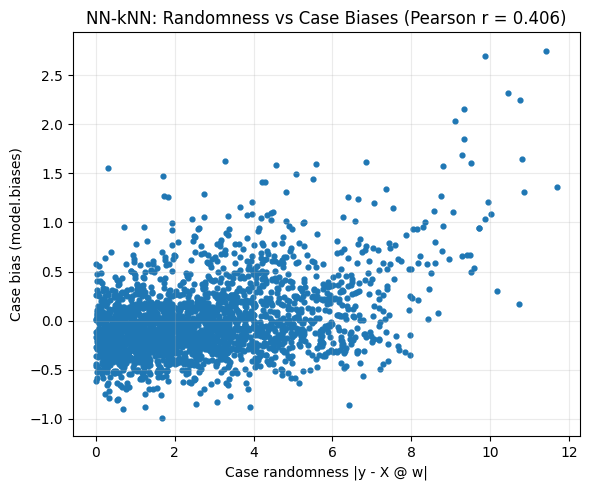

NameError: name 'r_w' is not defined

In [ ]:
# --- Case Randomness vs Case Weights/Biases ---
# Requirements: torch, matplotlib
# Assumes:
#   - X : [N, D] torch.Tensor  (training cases used to build `model`)
#   - y : [N, 1] torch.Tensor  (training labels used to build `model`)
#   - model : nnknn_model.NN_KNN_Model (already trained), where model.weights / model.biases are per-case
#   - true_w : optional torch.Tensor of shape [D, 1]; if absent, we estimate w_hat via OLS on (X, y)

import torch
import matplotlib.pyplot as plt

def compute_case_randomness(X, y, true_w=None):
    """
    Returns a 1D tensor of length N with per-case 'randomness' magnitudes.
    If true_w is provided, randomness_i = | y_i - X_i @ true_w |.
    Otherwise, it fits an OLS w_hat and uses | y_i - X_i @ w_hat |.
    """
    X_ = X.detach()
    y_ = y.detach().view(-1, 1)

    if true_w is None:
        # OLS: w_hat = (X^T X)^{-1} X^T y   (PINV is safer numerically)
        w_hat = torch.pinverse(X_.T @ X_) @ (X_.T @ y_)
        resid = y_ - X_ @ w_hat
    else:
        resid = y_ - X_ @ true_w.detach()

    # Magnitude of the noise term; use absolute value (you can switch to square by **2 if preferred)
    case_randomness = resid.abs().view(-1)  # [N]
    return case_randomness

@torch.no_grad()
def plot_randomness_correlations(model, X, y, true_w=None, title_prefix=""):
    # 1) Compute per-case randomness
    rnd = compute_case_randomness(X, y, true_w=true_w).cpu()

    # 2) Pull learned per-case weights & biases from the NN-kNN model
    # w_case = model.weights.detach().cpu().view(-1)   # [N]
    b_case = model.biases.detach().cpu().view(-1)    # [N]

    # 3) Simple Pearson correlations (no scipy needed)
    def pearson_r(a, b, eps=1e-12):
        a = a - a.mean()
        b = b - b.mean()
        num = (a * b).sum()
        den = (a.pow(2).sum().sqrt() * b.pow(2).sum().sqrt()).clamp_min(eps)
        return (num / den).item()

    # r_w  = pearson_r(rnd, w_case)
    r_b  = pearson_r(rnd, b_case)

    # 4) Plots
    # plt.figure(figsize=(6,5))
    # plt.scatter(rnd.numpy(), w_case.numpy(), s=12)
    # plt.xlabel("Case randomness |y - X @ w|")
    # plt.ylabel("Case weight (model.weights)")
    # plt.title(f"{title_prefix}Randomness vs Case Weights (Pearson r = {r_w:.3f})")
    # plt.grid(True, alpha=0.25)
    # plt.tight_layout()
    # plt.show()

    plt.figure(figsize=(6,5))
    plt.scatter(rnd.numpy(), b_case.numpy(), s=12)
    plt.xlabel("Case randomness |y - X @ w|")
    plt.ylabel("Case bias (model.biases)")
    plt.title(f"{title_prefix}Randomness vs Case Biases (Pearson r = {r_b:.3f})")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # print(f"Pearson correlation (randomness ↔ case weights): {r_w:.4f}")
    print(f"Pearson correlation (randomness ↔ case biases):  {r_b:.4f}")

# ---- Usage ----
# If you know true_w from your generator:
plot_randomness_correlations(model, X_train_raw, y_train_raw, true_w=true_w, title_prefix="NN-kNN: ")

# If you don't have true_w (e.g., on a real dataset), just omit it and it will use OLS residuals:
# plot_randomness_correlations(model, X, y, title_prefix="NN-kNN: ")


## Case Base Cleaning

What happens if we only keep cases with weights and biases that is more than 1 (their initial default values).

This experiment needs to generally applicable to whatever data set is being used

In [ ]:
#TODO,



# Depression physical symptoms: Explanation by feature


In [ ]:
import torch
import pandas as pd

# 1. Get the glocal feature weights from the trained model
# feature_weights shape: (set_num, feature_dim)
fw = model.glocal_weightor.feature_weights

print("feature_weights shape:", fw.shape)

# If you only have 1 weight set (most likely), take the first row
# If you have multiple, change set_idx to 1,2,... as needed
set_idx = 0
w = fw[set_idx].detach().cpu().view(-1)  # shape: [feature_dim]

# 2. Your column texts (exact list you gave)
columns = ['1. Most of the time I have difficulty concentrating on simple tasks',
 "2. I don't feel like doing my daily duties",
 '3. My friends or family have told me that I look different',
 '4. When I think about the future it is difficult for me to imagine it clearly',
 '5. People around me often ask me how I feel',
 '6. I consider that my life is full of good things',
 '7. My hobbies are still important to me',
 "8. I'm still as punctual as I have always been",
 '9. If I had the chance, I would spend all day in my bed',
 '10. I have found that I can spend a lot of time scrolling the screen \nof my cell phone without searching or stopping at anything in particular',
 '11. When someone asks me something, I have noticed that I take longer than normal to\nrespond',
 '12. I have noticed my body shaken without any cause',
 '13. I felt more encouraged to do my daily activities before',
 "14. Sometimes I wake up sad and I can't explain why",
 '15. In recent months I usually reproach myself for things from the past',
 '16. I think my thoughts are strange or different from before',
 '17. I feel guilty about the decisions that I have made',
 "18. I don't feel as comfortable with my body as I did before",
 "19. I don't feel successful compared to others",
 '20. It is difficult for me to make decisions even if they are simple',
 "21. I'm capable of achieving what I propose to myself",
 '22. It is not difficult for me to understand something the first time',
 '23. I have thought more than before about what my death would be like',
 '24. Being dead seems to be a solution to some problems',
 '25. I would rather stay home than go out with my friends',
 '26. I like to attend family gatherings',
 '27. I feel excited when thinking about my life project',
 '28. The decisions I have made so far have been the right ones',
 '29. I am able to carry out my activities as I have always been',
 '30. I like to be in touch with my friends and family through social media',
 '31. It is easy for me to choose a photograph of myself to show it on social media',
 '32. I am proud of what I have achieved so far',
 '33. I have trouble remembering things easily',
 '34. In recent months I have had discussions with my schoolmates or colleagues',
 '35. I constantly imagine that something will go wrong at my work or at school',
 '36. I am afraid of being worng when doing my homework',
 "37. I'm not too worried about what might happen in a few weeks",
 "38. Lately it's hard for me to calm down",
 '39. Everything will be alright',
 '40. I can easily blank my mind',
 '41. I am bothered by insignificant things that were not important before',
 '42. I find it uncomfortable to be in a crowded place',
 '43. Sometimes i feel trapped',
 '44. I am easily frightened by unexpected noises',
 '45. I have difficulties to do one task at a time',
 '46. I have the feeling that I am forgetting to do something',
 '47. I can clearly express to others how I feel',
 '48. I can sleep easily',
 '49. I enjoy every moment of the day',
 '50. I imagine that at any moment a disaster of the\nnature may occur',
 '51. Sometimes I feel like I get tired easily',
 '52. Being locked in an elevator would be the worst thing that could happen to me',
 "53. I'm bothered by people walking slowly in front of me ",
 "54. I don't usually get upset if something doesn't go as expected",
 '55. Sometimes it is as if some conversations with friends or family become\ninterrogations',
 '56. I manage my schedule as I always have',
 '57. It bothers me to feel that people on the street approach me',
 '58. I have no difficulty understanding what people explain to me',
 '59. I consider that I am good at controlling my emotions',
 '60. In new situations I feel calm and encouraged',
 '61. Sometimes I forget what I wanted to say because I have several thoughts at the same time',
 '62. I would like to know what will happen in the future',
 '63. When I get angry I can easily explode',
 '64. I can put down my cell phone and dedicate myself to reading without distractions',
 '65. I worry that people will not understand what I mean.',
 '66. Sometimes I do not listen to what people say to me because I am thinking about other things',
 '67. I get angry easily',
 "68. I'm afraid that something bad could happen to me",
 '69. It is not important for me to meet set dates',
 '70. I like to think clearly before giving my opinion',
 '71. I use lies just to get out of certain problems',
 '72. If I have the opportunity to get in line to avoid wasting time, I do it',
 '73. I have difficulty making elaborate plans',
 '74. People have problems because of themselves',
 '75. No me parece importante lo que los otros piensen sobre mí',
 '76. Laws are not as important as others think',
 '77. I would regret betraying a friend',
 '78. I prefer that a negotiation supports the largest possible number of people involved',
 '79. It is easy for me to work in a team',
 '80. It is important to help people when they need it',
 '81. I have punched someone or thought of doing it',
 '82. If it was necessary I would pretend to be someone else to get something',
 '83. I consider it important to ensure my physical safety and that of those around me',
 '84. After an argument I usually go over what happened in my head',
 '85. I have a hard time controlling myself when I get angry',
 '86. Loyalty is important',
 "87. If I can help a person I will stop what I'm doing to help him",
 '88',
 '89. It makes me laugh when my superiors at school or at work demand something',
 '90. Deceiving people is not wrong if it is to achieve something important',
 '91. I like to greet my neighbors',
 '92. It does not seem serious to me to have some debts',
 '93. People steal because they have needs',
 '94. I lose control easily',
 "95. Neighbors must put up with each other's noises without complaining",
 '96. Littering on public roads is wrong',
 '97. People who commit crimes have their reasons for doing it',
 '98. It is normal to change jobs several times a year',
 '99. It is important to respect turns',
 '100. I could pretend to be someone else to achieve what I want',
 '101. I consider it important that all people have the same rights',
 '102. I have a hard time taking  "no" for an answer']

assert len(columns) == len(w), f"{len(columns)=}, {len(w)=}"

# 3. Build a DataFrame and sort by descending weight
df = pd.DataFrame({
    "item_index": range(1, len(columns) + 1),
    "item_text": columns,
    "weight": w.numpy(),
})

df_sorted = df.sort_values("weight", ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', None)   # or a big number like 500

# Show top 15 most important items
df_sorted.head(15)


feature_weights shape: torch.Size([1, 5])


AssertionError: len(columns)=102, len(w)=5

In [ ]:
df_sorted.tail(15)

,item_index,item_text,weight
87,35,35. I constantly imagine that something will go wrong at my work or at school,0.456618
88,92,92. It does not seem serious to me to have some debts,0.445569
89,34,34. In recent months I have had discussions with my schoolmates or colleagues,0.440081
90,99,99. It is important to respect turns,0.398854
91,57,57. It bothers me to feel that people on the street approach me,0.389153
92,86,86. Loyalty is important,0.388535
93,59,59. I consider that I am good at controlling my emotions,0.369359
94,85,85. I have a hard time controlling myself when I get angry,0.357962
95,64,64. I can put down my cell phone and dedicate myself to reading without distractions,0.354957
96,91,91. I like to greet my neighbors,0.351390


# Sanity Check


Model Validation RMSE (z): 0.1678
Baseline KNN(X) RMSE (z):      0.2103
Oracle KNN(y_true) RMSE (z):   0.0033
Training MLKR...


C:\Users\xye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\xye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training KNN (with learned metric)...
MLKR+KNN RMSE (z):            0.2726
Training MLKR...


C:\Users\xye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\xye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training KNN (with learnt metric)...
Validation RMSE [RAW] (MLKR) for (sanity-check): 16447.3749
Model RMSE (raw units):       10121.0160
KNN(X) RMSE (raw units):      12683.6766
Oracle RMSE (raw units):      200.1220
MLKR+KNN RMSE (raw units):    16447.3744


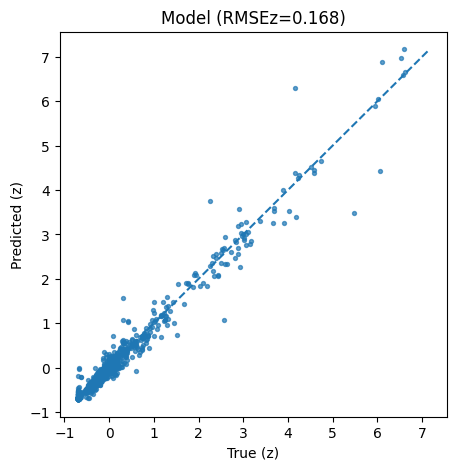

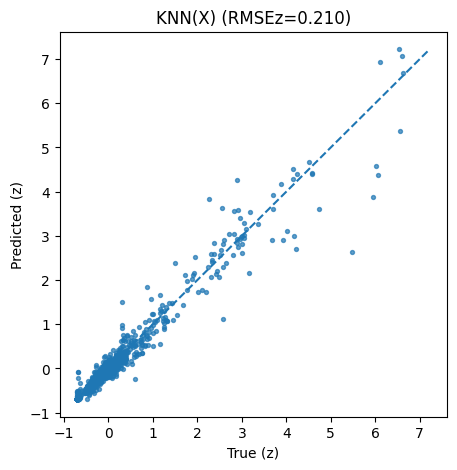

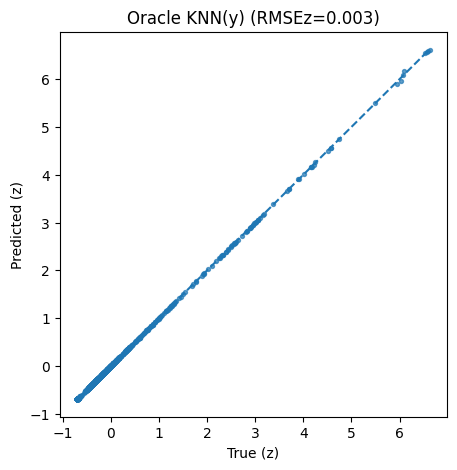

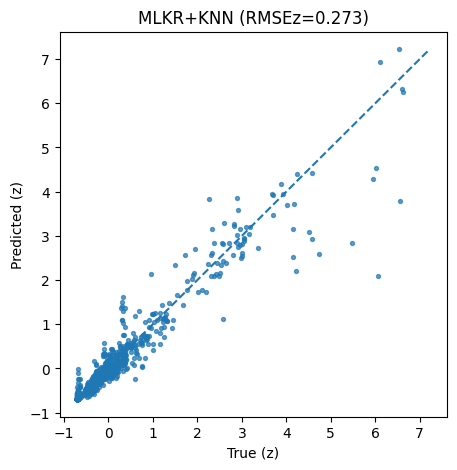

In [16]:
import sys
import pathlib

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- Make sure project root is on PYTHONPATH so `from model...` works ---
PROJECT_ROOT = pathlib.Path().resolve()  # assumes the notebook is run from project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Optional: import your MLKR helper (model/mlkr.py) ---
try:
    from model.mlkr import run_mlkr_sklearn
except Exception as e:
    run_mlkr_sklearn = None
    print("[warn] Could not import `model.mlkr`. If needed, ensure `model/__init__.py` exists and restart the kernel.")
    print("       Import error:", repr(e))

K_BSL = 5
B_DIST = 512

@torch.no_grad()
def knn_predict_by_X(X_train, y_train, X_query, k=K_BSL, batch_size=B_DIST, device=device):
    Xtr = X_train.to(device)
    ytr = y_train.to(device).view(-1)
    preds = []
    for i in range(0, X_query.size(0), batch_size):
        xq = X_query[i:i+batch_size].to(device)
        d = torch.cdist(xq, Xtr, p=2)
        vals, idx = torch.topk(d, k=k, largest=False)
        nbr_y = ytr[idx]
        w = 1.0 / (vals + 1e-12)
        w = w / w.sum(dim=1, keepdim=True).clamp_min(1e-12)
        preds.append((w * nbr_y).sum(dim=1).cpu())
    return torch.cat(preds, dim=0)

@torch.no_grad()
def knn_oracle_predict_by_y(y_train, y_true_val, k=K_BSL, batch_size=B_DIST, device=device):
    # "Oracle" KNN that uses y_true distances (upper bound sanity check)
    ytr = y_train.to(device).view(1, -1)
    preds = []
    for i in range(0, y_true_val.numel(), batch_size):
        yq = y_true_val[i:i+batch_size].to(device).view(-1, 1)
        dy = torch.abs(ytr - yq)
        vals, idx = torch.topk(dy, k=k, largest=False)
        nbr_y = ytr.squeeze(0)[idx]
        w = 1.0 / (vals + 1e-12)
        w = w / w.sum(dim=1, keepdim=True).clamp_min(1e-12)
        preds.append((w * nbr_y).sum(dim=1).cpu())
    return torch.cat(preds, dim=0)

# --- Model predictions (z-space) ---
model.eval()
with torch.no_grad():
    preds = []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, *_ = model(X_val[i:i+B].to(device))
        preds.append(yhat.detach().cpu().view(-1))
    y_pred_model_z = torch.cat(preds, dim=0).to(torch.float32)

y_true_z = y_val.detach().cpu().view(-1).to(torch.float32)

rmse_model_z = torch.sqrt(F.mse_loss(y_pred_model_z, y_true_z)).item()
print(f"Model Validation RMSE (z): {rmse_model_z:.4f}")

# --- Baselines (also z-space; y_train/y_val are z-scored in this notebook) ---
y_pred_knnX_z = knn_predict_by_X(X_train, y_train, X_val, k=K_BSL)
rmse_knnX_z = torch.sqrt(F.mse_loss(y_pred_knnX_z, y_true_z)).item()
print(f"Baseline KNN(X) RMSE (z):      {rmse_knnX_z:.4f}")

y_pred_knnY_z = knn_oracle_predict_by_y(y_train, y_true_z, k=K_BSL)
rmse_knnY_z = torch.sqrt(F.mse_loss(y_pred_knnY_z, y_true_z)).item()
print(f"Oracle KNN(y_true) RMSE (z):   {rmse_knnY_z:.4f}")

# --- MLKR baseline (metric-learn + sklearn KNN) ---
# NOTE: MLKR runs on CPU (sklearn); this is just a sanity-check baseline.
MLKR_K = 25
rmse_mlkr_z = None
y_pred_mlkr_z = None

try:
    from metric_learn import MLKR
    from sklearn.neighbors import KNeighborsRegressor

    Xtr_np = X_train.detach().cpu().numpy()
    ytr_np = y_train.detach().cpu().numpy().ravel()
    Xva_np = X_val.detach().cpu().numpy()

    print("Training MLKR...")
    mlkr = MLKR(
        n_components=None,         # set an int if you want a low-rank metric
        max_iter=1000,
        tol=1e-4,
        random_state=42,
    )
    mlkr.fit(Xtr_np, ytr_np)

    print("Training KNN (with learned metric)...")
    knn_mlkr = KNeighborsRegressor(
        n_neighbors=MLKR_K,
        weights="distance",
        metric=mlkr.get_metric(),   # Mahalanobis metric from MLKR
        algorithm="brute",
    )
    knn_mlkr.fit(Xtr_np, ytr_np)

    y_pred_mlkr_z = torch.from_numpy(knn_mlkr.predict(Xva_np)).to(torch.float32)
    rmse_mlkr_z = torch.sqrt(F.mse_loss(y_pred_mlkr_z, y_true_z)).item()
    print(f"MLKR+KNN RMSE (z):            {rmse_mlkr_z:.4f}")

    # If you want to verify via your helper function too (prints RAW RMSE):
    if run_mlkr_sklearn is not None:
        _ = run_mlkr_sklearn(
            X_train, y_train, X_val, y_val,
            cfg=dict(k=MLKR_K, n_components=None, max_iter=1000, dataset_name="(sanity-check)"),
            y_mean_raw=y_mean_raw,
            y_std_raw=y_std_raw,
        )

except ImportError:
    print("[warn] MLKR baseline skipped (missing deps). Install with:")
    print("       pip install metric-learn scikit-learn")

# --- Convert to raw units (since you stored y_std_raw from the original y) ---
if "y_std_raw" in globals():
    raw_std = float(y_std_raw)
    rmse_model_raw = rmse_model_z * raw_std
    rmse_knnX_raw  = rmse_knnX_z  * raw_std
    rmse_knnY_raw  = rmse_knnY_z  * raw_std
    print(f"Model RMSE (raw units):       {rmse_model_raw:.4f}")
    print(f"KNN(X) RMSE (raw units):      {rmse_knnX_raw:.4f}")
    print(f"Oracle RMSE (raw units):      {rmse_knnY_raw:.4f}")
    if rmse_mlkr_z is not None:
        rmse_mlkr_raw = rmse_mlkr_z * raw_std
        print(f"MLKR+KNN RMSE (raw units):    {rmse_mlkr_raw:.4f}")

# --- Plots in z-space (consistent) ---
def ovp_plot(y_t, y_p, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_t.numpy(), y_p.numpy(), s=8, alpha=0.7)
    mn = float(min(y_t.min().item(), y_p.min().item()))
    mx = float(max(y_t.max().item(), y_p.max().item()))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("True (z)")
    plt.ylabel("Predicted (z)")
    plt.title(title)
    plt.show()

ovp_plot(y_true_z, y_pred_model_z, f"Model (RMSEz={rmse_model_z:.3f})")
ovp_plot(y_true_z, y_pred_knnX_z,  f"KNN(X) (RMSEz={rmse_knnX_z:.3f})")
ovp_plot(y_true_z, y_pred_knnY_z,  f"Oracle KNN(y) (RMSEz={rmse_knnY_z:.3f})")
if y_pred_mlkr_z is not None:
    ovp_plot(y_true_z, y_pred_mlkr_z, f"MLKR+KNN (RMSEz={rmse_mlkr_z:.3f})")


In [17]:
X_train.device

device(type='cpu')

In [18]:
device

device(type='cuda')

##  MLP

MLP Baseline RMSE (z): 0.2728
MLP Baseline RMSE (raw): 16455.4707


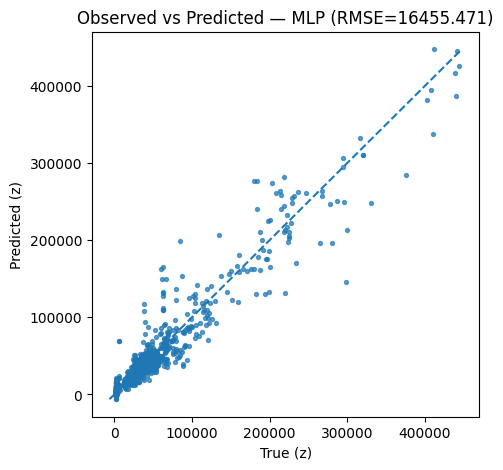

In [19]:
# ===== Baseline 3: Multilayer Perceptron (regression) =====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Use standardized tensors (you overwrote earlier)
X_train_z = X_train.to(device)
X_val_z   = X_val.to(device)
y_train_z = y_train.to(device).view(-1)
y_val_z   = y_val.to(device).view(-1)

train_ds = TensorDataset(X_train_z, y_train_z)
val_ds   = TensorDataset(X_val_z,   y_val_z)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)

class MLPReg(nn.Module):
    def __init__(self, in_dim, hidden=(64, 32), dropout=0.10):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            if dropout and dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)   # predicts y in z-space

mlp = MLPReg(in_dim=X_train.shape[1], hidden=(64, 32), dropout=0.10).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

@torch.no_grad()
def val_rmse_z(model):
    model.eval()
    preds, trues = [], []
    for xb, yb in val_loader:
        preds.append(model(xb.to(device)).cpu())
        trues.append(yb.cpu())
    yp = torch.cat(preds).view(-1)
    yt = torch.cat(trues).view(-1)
    return torch.sqrt(F.mse_loss(yp, yt)).item()

best_rmse, best_state = float("inf"), None
patience, wait = 20, 0
EPOCHS = 200

for epoch in range(1, EPOCHS + 1):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = mlp(xb)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), 1.0)
        opt.step()

    rmse_val = val_rmse_z(mlp)
    if rmse_val + 1e-6 < best_rmse:
        best_rmse = rmse_val
        best_state = {k: v.detach().clone() for k, v in mlp.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait > patience:
            break

if best_state is not None:
    mlp.load_state_dict(best_state)

# --- Predict on validation (z-space, consistent) ---
mlp.eval()
with torch.no_grad():
    preds_mlp_z = []
    for i in range(0, X_val_z.size(0), 512):
        preds_mlp_z.append(mlp(X_val_z[i:i+512]).cpu())
    y_pred_mlp_z = torch.cat(preds_mlp_z).view(-1).to(torch.float32)

y_true_z = y_val_z.detach().cpu().view(-1).to(torch.float32)
rmse_mlp_z = torch.sqrt(F.mse_loss(y_pred_mlp_z, y_true_z)).item()
print(f"MLP Baseline RMSE (z): {rmse_mlp_z:.4f}")

# --- Optional: convert to raw units if you saved train-split y scaler ---
if "y_mean_raw" in globals() and "y_std_raw" in globals():
    y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
    y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

    y_pred_mlp_raw = y_pred_mlp_z * y_std_t + y_mean_t
    y_true_raw     = y_true_z     * y_std_t + y_mean_t

    rmse_mlp_raw = torch.sqrt(F.mse_loss(y_pred_mlp_raw, y_true_raw)).item()
    print(f"MLP Baseline RMSE (raw): {rmse_mlp_raw:.4f}")

    ovp_plot(y_true_raw, y_pred_mlp_raw, f"Observed vs Predicted — MLP (RMSE={rmse_mlp_raw:.3f})")
else:
    # Plot in z-space if raw scaler isn't available
    ovp_plot(y_true_z.cpu(), y_pred_mlp_z.cpu(), f"Observed vs Predicted — MLP (RMSEz={rmse_mlp_z:.3f})")


## Extract MLP feature extractor

In [20]:
# # ===== Use pretrained MLP trunk as NN-kNN feature extractor =====
# import copy
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class PretrainedMLPTrunkExtractor(nn.Module):
#     """
#     Standardize X using TRAIN stats, then run the pretrained MLP trunk (no last layer).
#     Output is the penultimate representation (embedding) used for NN-kNN distances.
#     """
#     def __init__(self, mlp_model: nn.Module, X_mean: torch.Tensor, X_std: torch.Tensor, remove_dropout: bool = True):
#         super().__init__()
#         # buffers so they move with .to(device) and get saved with the model
#         self.register_buffer("X_mean", X_mean.detach().clone())
#         self.register_buffer("X_std",  X_std.detach().clone())

#         # trunk = all layers except the last Linear->1
#         trunk = copy.deepcopy(mlp_model.net[:-1])

#         if remove_dropout:
#             trunk = nn.Sequential(*[
#                 nn.Identity() if isinstance(l, nn.Dropout) else l
#                 for l in trunk
#             ])

#         self.trunk = trunk

#         # optional: expose output dim
#         out_dim = None
#         for l in reversed(self.trunk):
#             if isinstance(l, nn.Linear):
#                 out_dim = l.out_features
#                 break
#         self.feature_dim = out_dim

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         if x.dim() > 2:
#             x = x.view(x.size(0), -1)
#         x = (x - self.X_mean) / (self.X_std + 1e-8)
#         return self.trunk(x)

# # Build extractor from trained MLP (uses the SAME X_mean/X_std you computed in the MLP cell)
# mlp_extractor = PretrainedMLPTrunkExtractor(mlp, X_mean, X_std, remove_dropout=True).to(device)
# print("Extractor feature_dim:", mlp_extractor.feature_dim)

# # ---- NN-kNN config for this experiment (start simple + stable) ----
# import copy
# cfg_pt = copy.deepcopy(cfg)

# # IMPORTANT: don't stack another random post-MLP on top of the pretrained trunk
# cfg_pt["post_mlp_enabled"] = False

# # Start without NN-CDH and locality; add them back later once retrieval matches MLP
# cfg_pt["use_nn_cdh"] = False
# cfg_pt["nn_cdh_pretrain"] = False
# cfg_pt["regression_locality"] = False

# # Make retrieval as KNN-like as possible first
# cfg_pt["case_score_mode"] = "neg_distance"     # use pure distance ranking first
# cfg_pt["case_normalizer"] = "softmax"          # keep stable
# cfg_pt["tau"] = 1.0                            # sweep later: 0.3, 0.7, 1.0, 2.0

# # Since bias isn't used in neg_distance mode, turn off bias regularizer for this run
# cfg_pt["lambda_case_bias"] = 0.0

# # Feature-extractor LR will matter only after unfreezing; keep it small
# cfg_pt["feature_extractor_lr"] = 1e-5

# # Freeze schedule (requires tiny patch to train_model shown below)
# cfg_pt["freeze_feature_extractor_epochs"] = 500  # e.g., 200–800

# # Run training
# # use raw features since extractor does standardization internally
# best_acc, glocal_weightor, model = train_model(
#     X_train_raw, y_train,
#     X_val_raw,   y_val,
#     feature_extractor=mlp_extractor,
#     cfg=cfg_pt
# )


[Z] Pre-adaptation  RMSE: 0.9638
[Z] Post-adaptation RMSE: 244.2178
[Z] ΔRMSE (pre - post):  -243.2541
[RAW] Pre-adaptation  RMSE: 58139.3281
[RAW] Post-adaptation RMSE: 14732597.0000


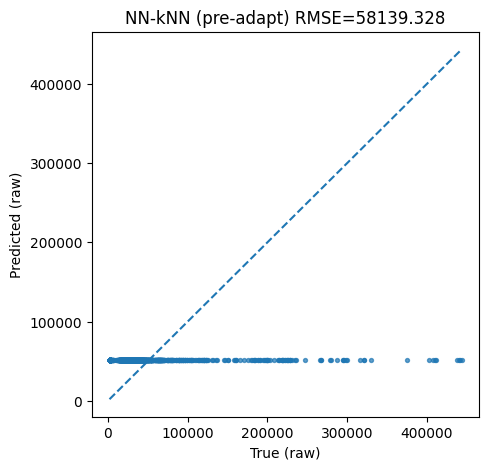

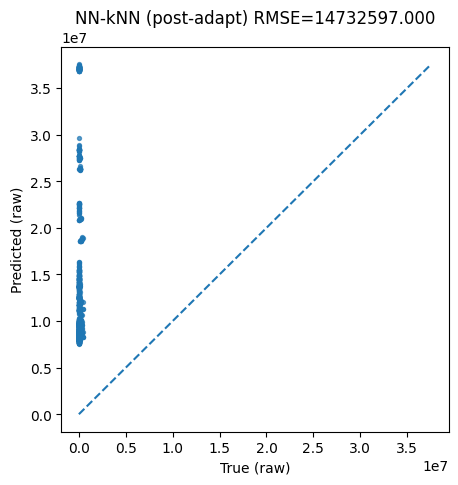

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pre_preds, post_preds = [], []
    B = 512
    for i in range(0, X_val_raw.size(0), B):
        _, yhat, pre_adapt_yhat, *_ = model(X_val_raw[i:i+B].to(device))

        # normalize shape to [B]
        if pre_adapt_yhat.dim() == 3:
            pre_yhat = pre_adapt_yhat.sum(dim=1).squeeze(-1)
        elif pre_adapt_yhat.dim() == 2:
            pre_yhat = pre_adapt_yhat.squeeze(-1)
        else:
            pre_yhat = pre_adapt_yhat

        post_preds.append(yhat.detach().cpu().view(-1))
        pre_preds.append(pre_yhat.detach().cpu().view(-1))

    y_pred_post_z = torch.cat(post_preds, dim=0).to(torch.float32)
    y_pred_pre_z  = torch.cat(pre_preds,  dim=0).to(torch.float32)
    y_true_z      = y_val.detach().cpu().view(-1).to(torch.float32)  # assumes y_val is z-scored

# --- RMSE in z-space (always correct if y_val is z) ---
rmse_pre_z  = torch.sqrt(F.mse_loss(y_pred_pre_z,  y_true_z)).item()
rmse_post_z = torch.sqrt(F.mse_loss(y_pred_post_z, y_true_z)).item()
print(f"[Z] Pre-adaptation  RMSE: {rmse_pre_z:.4f}")
print(f"[Z] Post-adaptation RMSE: {rmse_post_z:.4f}")
print(f"[Z] ΔRMSE (pre - post):  {rmse_pre_z - rmse_post_z:.4f}")

# --- Optional: convert to raw units if you saved train-split scaler ---
if "y_mean_raw" in globals() and "y_std_raw" in globals():
    y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
    y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

    y_true_raw      = y_true_z      * y_std_t + y_mean_t
    y_pred_pre_raw  = y_pred_pre_z  * y_std_t + y_mean_t
    y_pred_post_raw = y_pred_post_z * y_std_t + y_mean_t

    rmse_pre_raw  = torch.sqrt(F.mse_loss(y_pred_pre_raw,  y_true_raw)).item()
    rmse_post_raw = torch.sqrt(F.mse_loss(y_pred_post_raw, y_true_raw)).item()
    print(f"[RAW] Pre-adaptation  RMSE: {rmse_pre_raw:.4f}")
    print(f"[RAW] Post-adaptation RMSE: {rmse_post_raw:.4f}")

    # Plot in raw units
    def ovp_plot(y_t, y_p, title):
        plt.figure(figsize=(5,5))
        plt.scatter(y_t.numpy(), y_p.numpy(), s=8, alpha=0.7)
        mn = float(min(y_t.min().item(), y_p.min().item()))
        mx = float(max(y_t.max().item(), y_p.max().item()))
        plt.plot([mn, mx], [mn, mx], linestyle='--')
        plt.xlabel('True (raw)')
        plt.ylabel('Predicted (raw)')
        plt.title(title)
        plt.show()

    ovp_plot(y_true_raw.cpu(), y_pred_pre_raw.cpu(),  f"NN-kNN (pre-adapt) RMSE={rmse_pre_raw:.3f}")
    ovp_plot(y_true_raw.cpu(), y_pred_post_raw.cpu(), f"NN-kNN (post-adapt) RMSE={rmse_post_raw:.3f}")
else:
    print("Tip: define y_mean_raw/y_std_raw (train-split stats) if you want RMSE in raw units.")


## MLP's most similar cases

In [22]:
# ---------------------------------------------------
# 2) Penultimate-layer features from your MLP
# ---------------------------------------------------
def mlp_penultimate_features(model, X_z, batch_size=512, device=device):
    """
    Compute penultimate-layer features for all samples in X_z using your MLPReg.

    X_z: standardized inputs (like X_train_z, X_val_z), shape [N, D]
    Returns: tensor of shape [N, H_penultimate]
    """
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, X_z.size(0), batch_size):
            xb = X_z[i:i+batch_size].to(device)
            # model.net is Sequential: [Linear, ReLU, Dropout, ..., Linear(->1)]
            # We take all but the last Linear to get the penultimate representation.
            hb = model.net[:-1](xb)            # [B, H_penultimate]
            feats.append(hb.cpu())
    return torch.cat(feats, dim=0)             # [N, H_penultimate]


# ---------------------------------------------------
# 3) Average ground-truth distance of MLP's top-k neighbors
# ---------------------------------------------------
def avg_true_distance_mlp(
    mlp_model,
    X_train_orig, X_train_z,
    X_query_orig, X_query_z,
    feature_weights,
    k=5,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    Use MLP penultimate features for k-NN retrieval, but evaluate neighbor
    quality using ground-truth weighted distance in ORIGINAL feature space.

    X_train_orig:  [N_train, D]  original input space (not standardized)
    X_train_z:     [N_train, D]  standardized (what MLP was trained on)
    X_query_orig:  [N_query, D]  original input space
    X_query_z:     [N_query, D]  standardized

    feature_weights:
        [D]      single-regime ground-truth feature weights (old behavior)
        or
        [R, D]   multi-regime weights when use_regime_weights=True

    use_regime_weights:
        - False (default): behaves like the original version, ignores regimes.
        - True: feature_weights must be [R, D] and regime_labels_query must be provided.
    """
    X_train_orig   = X_train_orig.to(device)
    X_query_orig   = X_query_orig.to(device)
    feature_weights = feature_weights.to(device)

    # 1) Extract features in MLP representation space
    train_feats = mlp_penultimate_features(mlp_model, X_train_z, device=device).to(device)  # [N_train, H]
    query_feats = mlp_penultimate_features(mlp_model, X_query_z, device=device).to(device)  # [N_query, H]

    # Decide whether to use per-regime weights
    use_regime = False
    if use_regime_weights and feature_weights.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == X_query_orig.shape[0], \
            "regime_labels_query must have same length as X_query_orig."
        use_regime = True

    all_topk_means = []

    with torch.no_grad():
        for i in range(query_feats.size(0)):
            q_feat = query_feats[i]                     # [H]

            # --- k-NN in feature space (no need for sqrt, ranking is identical) ---
            diffs_feat = train_feats - q_feat.unsqueeze(0)   # [N_train, H]
            d_feat_sq  = (diffs_feat ** 2).sum(dim=-1)       # [N_train]
            topk_idx   = torch.topk(d_feat_sq, k=k, largest=False).indices  # [k]

            # --- Evaluate those neighbors in original space with true weights ---
            q_raw     = X_query_orig[i]               # [D]
            neigh_raw = X_train_orig[topk_idx]        # [k, D]

            if use_regime:
                regime_idx = int(regime_labels_query[i].item())
            else:
                regime_idx = None

            d_true = weighted_l2_distance(q_raw, neigh_raw, feature_weights, regime_idx=regime_idx)  # [k]
            all_topk_means.append(d_true.mean().item())

    return float(sum(all_topk_means) / len(all_topk_means))





In [23]:
k_eval = 5  # or whatever k you want for comparison

if regime_weights:
    mlp_avg_dist = avg_true_distance_mlp(
        mlp_model          = mlp,
        X_train_orig       = X_train,
        X_train_z          = X_train_z,
        X_query_orig       = X_val,
        X_query_z          = X_val_z,
        feature_weights    = true_feature_weights_glocal,  # [2, D]
        k                  = k_eval,
        device             = device,
        use_regime_weights = True,
        regime_labels_query= regime_labels_val             # [N_val], 0/1
    )
else:
    mlp_avg_dist = avg_true_distance_mlp(
        mlp_model          = mlp,
        X_train_orig       = X_train,
        X_train_z          = X_train_z,
        X_query_orig       = X_val,
        X_query_z          = X_val_z,
        feature_weights    = true_feature_weights,         # [D]
        k                  = k_eval,
        device             = device
    )

print(f"MLP — mean ground-truth distance of top-{k_eval} neighbors: {mlp_avg_dist:.4f}")


NameError: name 'true_feature_weights' is not defined